In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from liu_inertia_estimation import *
from generate_noise import * 
from archive.calculate_metrics import calculate_inertia_rmse, convergence_time

In [5]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
out_dir = project_dir / "out/2_noise"
sim_out = project_dir / "out/simulation_data/simulation_timeseries.csv"

## Load in Simulation Time-Series Data

In [3]:
simulation_timeseries = pd.read_csv(sim_out)
H_TRUE = 5

In [4]:
t_est = simulation_timeseries.time
omega = simulation_timeseries["omega_int"]
power = simulation_timeseries["Pe_pu"]

## Demonstration of Filter Effects

In [5]:
noise = ou_noise(len(t_est))
noise

array([ 1.25730221e-05,  7.88460056e-06,  2.72560993e-05, ...,
       -8.93703186e-05, -3.41453331e-05, -1.99463805e-05], shape=(12000,))

In [6]:
taus_test = [0.02, 0.2]
colors = [ "#4B88C8", "#1128D3"]   

rocof_raw = np.gradient(omega, t_est) + noise
_dts = np.diff(t_est, prepend=t_est[0])
outs = {ta: lowpass_filter(rocof_raw, _dts, ta)[0] for ta in taus_test}


Filtering introduces a response delay but removes noise!

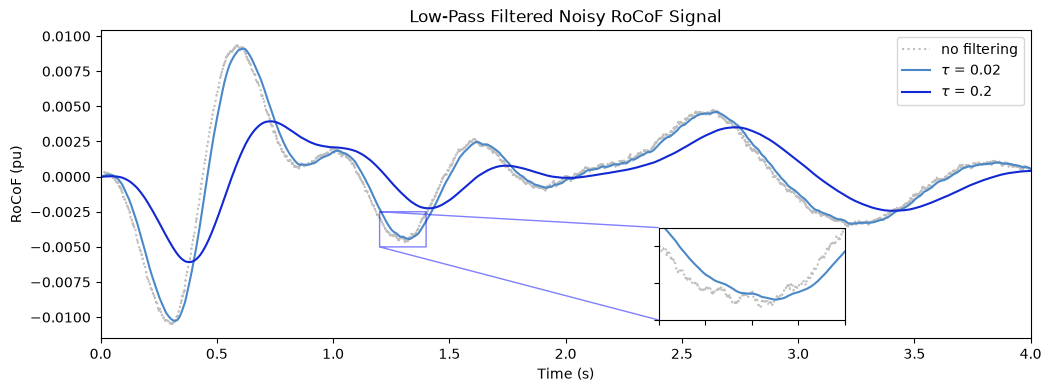

In [40]:
fig, ax = plt.subplots(figsize=(12, 4))

axins = ax.inset_axes(
        [0.6, 0.06, 0.2, 0.3],  # [x, y, width, height] w.r.t. axes
        xlim=[1.2, 1.4], ylim=[-0.005,-0.0025], # sets viewport & tells relation to main axes
        xticklabels=[], yticklabels=[] )

ax.plot(t_est, rocof_raw, color="gray", linestyle=":", alpha=0.5, label="no filtering")
axins.plot(t_est, rocof_raw, color="gray", linestyle=":", alpha=0.5)

for i, (tau, filtered) in enumerate(outs.items()):
    ax.plot(t_est, filtered, color=colors[i], label=f"$\\tau$ = {tau}")
    axins.plot(t_est, filtered, color=colors[i])

    # add indicators for the inset
ax.indicate_inset_zoom(axins, edgecolor="blue")
    

ax.set_title("Low-Pass Filtered Noisy RoCoF Signal")
ax.set_xlim(0, 4)
ax.set_xlabel("Time (s)")
ax.set_ylabel("RoCoF (pu)")



ax.legend()

## Run Through Estimators

In [112]:
STEP_TIME = 0.001
MONTE_CARLO_RUNS = 200

tau_vals = np.round(np.logspace(np.log10(0.005), np.log10(0.160), 20), 7) # 20 log-spaced values (values on the lower end are expected to make more sense)
rec_h_vals = tau_vals # record H timeseries ~~every 2nd value~~
noise_paths = [ou_noise(len(t_est), seed=i) for i in range(MONTE_CARLO_RUNS)]

tau_vals

array([0.005    , 0.0060005, 0.0072012, 0.0086422, 0.0103716, 0.0124469,
       0.0149376, 0.0179266, 0.0215138, 0.0258188, 0.0309852, 0.0371854,
       0.0446263, 0.0535562, 0.0642729, 0.0771341, 0.0925688, 0.1110921,
       0.1333219, 0.16     ])

In [113]:
runs_data = []
h_series_raw = {}

this_takes_too_long = len(tau_vals)
for i, tau in enumerate(tau_vals):
    rec = tau in rec_h_vals
    print(f"Running {i+1}/{this_takes_too_long}, tau={tau}. Recording = {rec}")

    clean = run_all_estimators(omega, power, t_est, tau, noise=None)
    print(" - ran clean estimator")
    noisy = [run_all_estimators(omega, power, t_est, tau, noise=noise) for noise in noise_paths]
    print(" - ran noise paths")

    # record
    for est in ['E0', 'E1', 'E2']:
        estimator_series = []

        e_s, iqr_s, tail_s = [], [], []
        cv = clean[est][np.isfinite(clean[est])]
        bias_clean = (100 * (np.median(cv) - H_TRUE) / H_TRUE if cv.size else np.nan) # percentage bias

        # aggregation across seeds
        for r in noisy:
            v = r[est][np.isfinite(r[est])]
            if not v.size:
                    continue
            pe = 100 * (v - H_TRUE) / H_TRUE # percent error

            e_s.append(np.median(pe))
            iqr_s.append(np.percentile(pe, 75) - np.percentile(pe, 25))
            tail_s.append(np.mean(np.abs(pe) > 50))
            if rec:
                estimator_series.append(r[est])

        e_s = np.array(e_s)
        runs_data.append({
            'est': est, 
            'tau_ms': round(tau * 1e3, 4),
            'cutoff_freq': 1 / (2 * np.pi * tau), 
            'rmse': np.sqrt(np.mean(e_s ** 2)),
            'bias': e_s.mean(), 
            'spread': e_s.std(ddof=1),
            'bias_clean': bias_clean,
            'bias_noise': e_s.mean() - bias_clean,
            'disp_iqr': np.median(iqr_s),
            'frac_gt50': np.mean(tail_s)
        })   

        # time-series aggregation if recording
        if rec:
            q75_ts, q25_ts = np.percentile(estimator_series, [75, 25],axis=0) # IQR along simulation axis
            mean_ts = np.mean(estimator_series, axis=0)
            h_series_raw[(est, str(round(tau * 1e3, 4)), "q50")] = mean_ts
            h_series_raw[(est, str(round(tau * 1e3, 4)), "q75")] = q75_ts
            h_series_raw[(est, str(round(tau * 1e3, 4)), "q25")] = q25_ts

    print(" - aggregation and recording complete")

runs_data         

Running 1/20, tau=0.005. Recording = True
 - ran clean estimator
 - ran noise paths
 - aggregation and recording complete
Running 2/20, tau=0.0060005. Recording = True
 - ran clean estimator
 - ran noise paths
 - aggregation and recording complete
Running 3/20, tau=0.0072012. Recording = True
 - ran clean estimator
 - ran noise paths
 - aggregation and recording complete
Running 4/20, tau=0.0086422. Recording = True
 - ran clean estimator
 - ran noise paths
 - aggregation and recording complete
Running 5/20, tau=0.0103716. Recording = True
 - ran clean estimator
 - ran noise paths
 - aggregation and recording complete
Running 6/20, tau=0.0124469. Recording = True
 - ran clean estimator
 - ran noise paths
 - aggregation and recording complete
Running 7/20, tau=0.0149376. Recording = True
 - ran clean estimator
 - ran noise paths
 - aggregation and recording complete
Running 8/20, tau=0.0179266. Recording = True
 - ran clean estimator
 - ran noise paths
 - aggregation and recording compl

[{'est': 'E0',
  'tau_ms': np.float64(5.0),
  'cutoff_freq': np.float64(31.830988618379067),
  'rmse': np.float64(32.44718790440723),
  'bias': np.float64(-32.41983525706181),
  'spread': np.float64(1.3353654230013456),
  'bias_clean': np.float64(2.949831498188864),
  'bias_noise': np.float64(-35.36966675525068),
  'disp_iqr': np.float64(106.77016464525559),
  'frac_gt50': np.float64(0.5773033333333334)},
 {'est': 'E1',
  'tau_ms': np.float64(5.0),
  'cutoff_freq': np.float64(31.830988618379067),
  'rmse': np.float64(42.72265865848179),
  'bias': np.float64(-42.66038268496091),
  'spread': np.float64(2.3117162850900246),
  'bias_clean': np.float64(1.9867228633984269),
  'bias_noise': np.float64(-44.647105548359335),
  'disp_iqr': np.float64(55.80183147598742),
  'frac_gt50': np.float64(0.45152416666666667)},
 {'est': 'E2',
  'tau_ms': np.float64(5.0),
  'cutoff_freq': np.float64(31.830988618379067),
  'rmse': np.float64(41.35429251097116),
  'bias': np.float64(-41.27836000273098),
  's

In [116]:
results = pd.DataFrame(runs_data)
results.set_index(["est", "tau_ms"], inplace=True)
results.sort_index(inplace=True)
results.to_csv(out_dir / "sweep_metrics.csv")


In [118]:
h_series_raw

{('E0',
  '5.0',
  'q50'): array([-3.05010574e-01, -2.36088243e-01, -1.66945651e+00, ...,
        -2.15782620e+00,  4.40778290e-03,  1.09040791e+01], shape=(12000,)),
 ('E0',
  '5.0',
  'q75'): array([1.00368809, 1.13531161, 1.47715191, ..., 1.37212509, 1.56108796,
        1.7319621 ], shape=(12000,)),
 ('E0',
  '5.0',
  'q25'): array([-1.07242643, -1.04344687, -0.9955656 , ..., -1.19772602,
        -1.361413  , -1.71986176], shape=(12000,)),
 ('E1',
  '5.0',
  'q50'): array([0.00000000e+00, 2.29753909e-04, 3.37904686e-03, ...,
        2.67469492e-01, 2.67445100e-01, 2.67629982e-01], shape=(12000,)),
 ('E1',
  '5.0',
  'q75'): array([0.        , 0.00143821, 0.01314289, ..., 0.34010645, 0.33920546,
        0.33756513], shape=(12000,)),
 ('E1',
  '5.0',
  'q25'): array([ 0.        , -0.00143804, -0.01310014, ...,  0.2015993 ,
         0.20011231,  0.2029843 ], shape=(12000,)),
 ('E2',
  '5.0',
  'q50'): array([0.00000000e+00, 2.29753909e-04, 3.37904686e-03, ...,
        3.07533931e-01, 3

In [121]:
h_series = pd.DataFrame(h_series_raw)
h_series.set_index(t_est, inplace=True)
h_series.sort_index(axis=1, inplace=True)
h_series.to_csv(out_dir / "h_series.csv")

## E2 Noise-Lag Tradeoff Curve

# Visualizations!

In [153]:
blue_shades = ["#8DF7D5", "#44C8ED", "#4285F2","#3C3CDA"]
red_shades = ["#FF009D", "#FF1100", "#F2A228", "#EBEB3E"]
green_shades = ["#B4F64B", "#4DA33D", "#3BF37B", "#32C8D0"]
colors = {
    "E0": blue_shades,
    "E1": plt.colormaps['spring'].resampled(4)(np.linspace(0, 1, 4)),
    "E2": plt.colormaps['summer'].resampled(4)(np.linspace(0, 1, 4))
}



In [131]:
results = pd.read_csv(out_dir / "sweep_metrics.csv", index_col="est")
#results

### RMSE & Dispersion vs. tau

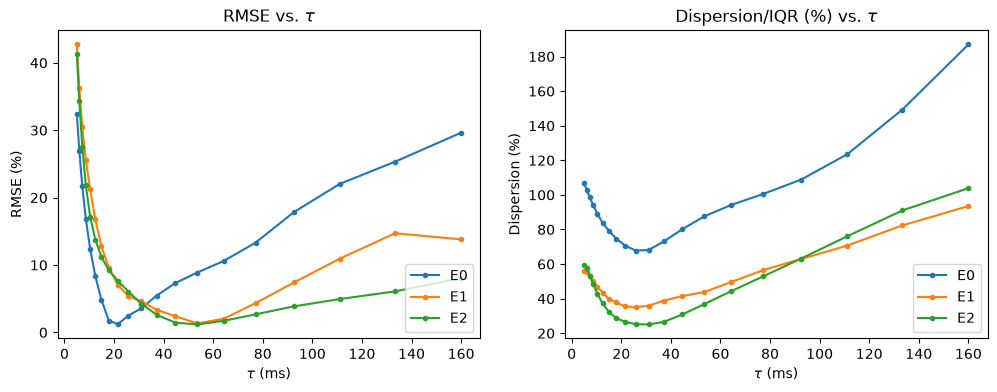

In [ ]:

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

ax_rmse = axes[0]
ax_disp = axes[1]

# plotting~
for est in ["E0", "E1", "E2"]:
    e = results.loc[est]
    ax_rmse.plot(e.tau_ms, e.rmse, marker="o", markersize=3, label=est)
    ax_disp.plot(e.tau_ms, e.disp_iqr, marker="o", markersize=3, label=est)


# RMSE labeling
ax_rmse.set_title(f"RMSE vs. $\\tau$")
ax_rmse.set_ylabel("RMSE (%)")
ax_rmse.set_xlabel("$\\tau$ (ms)")

ax_rmse.legend(loc="lower right")

# dispersion labeling
ax_disp.set_title(f"Dispersion/IQR (%) vs. $\\tau$")
ax_disp.set_ylabel("Dispersion (%)")
ax_disp.set_xlabel("$\\tau$ (ms)")

ax_disp.legend(loc="lower right")


## Time-Series Visualizations

In [ ]:
h_series = pd.read_csv(out_dir / "h_series.csv", index_col=0, header=[0, 1, 2])


In [12]:
h_series.columns.names = ["estimator", "tau", "percentile"]
h_series

estimator           E0                                                        \
tau            10.3716                        111.0921                         
percentile         q25        q50       q75        q25        q50        q75   
time                                                                           
1.110223e-15 -2.224556  -0.632690  2.081970 -23.827621  -6.776853  22.300363   
1.000000e-04 -2.142462  -0.484749  2.331084 -22.749617  -5.147284  24.752487   
9.000000e-04 -1.898827   1.356217  2.838421 -18.840291  36.784742  28.355644   
1.000000e-03 -1.886991   1.842654  2.535405 -19.246488  12.384095  26.107329   
1.100000e-03 -1.874868  -2.648042  2.759335 -17.899620  11.073579  29.661557   
...                ...        ...       ...        ...        ...        ...   
3.998100e+00 -1.659008   2.168053  2.604390   6.216946   8.101608  13.177945   
3.998900e+00 -1.694864  -1.142806  2.466874   6.226316  12.641065  13.026094   
3.999000e+00 -2.041116 -11.853607  2.251710   6.493666 -55.415874  13.619485   
3.999100e+00 -2.202880   0.665888  2.429350   6.708178  22.128506  13.768388   
3.999900e+00 -2.468687   1.111942  2.608421   6.722210  10.815177  13.778969   

estimator                                               ...        E2  \
tau            12.4469                        133.3219  ...    7.2012   
percentile         q25        q50       q75        q25  ...       q75   
time                                                    ...             
1.110223e-15 -2.669677  -0.759287  2.498561 -28.595586  ...  0.000000   
1.000000e-04 -2.567063  -0.580819  2.793067 -27.297777  ...  0.001439   
9.000000e-04 -2.247687   2.129263  3.364447 -22.579667  ...  0.013181   
1.000000e-03 -2.245137   1.970615  3.027186 -23.068548  ...  0.014663   
1.100000e-03 -2.211214  -1.992522  3.297997 -21.442403  ...  0.016162   
...                ...        ...       ...        ...  ...       ...   
3.998100e+00 -2.006174 -11.172251  3.025694   8.091424  ...  0.681371   
3.998900e+00 -1.638691   2.662004  2.743262   8.070490  ...  0.681949   
3.999000e+00 -2.127737   5.788371  2.493167   8.217975  ...  0.682919   
3.999100e+00 -2.153584   1.100665  2.872623   8.397961  ...  0.683791   
3.999900e+00 -2.359768   1.504962  2.991446   9.265237  ...  0.685927   

estimator                                                                 \
tau            77.1341                        8.6422                       
percentile         q25       q50       q75       q25       q50       q75   
time                                                                       
1.110223e-15  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1.000000e-04 -0.001440  0.000230  0.001440 -0.001439  0.000230  0.001439   
9.000000e-04 -0.013271  0.003425  0.013274 -0.013170  0.003398  0.013196   
1.000000e-03 -0.014770  0.003785  0.014775 -0.014637  0.003755  0.014681   
1.100000e-03 -0.016291  0.004160  0.016306 -0.016075  0.004118  0.016185   
...                ...       ...       ...       ...       ...       ...   
3.998100e+00  3.599001  3.834303  4.071936  0.707125  0.816358  0.926331   
3.998900e+00  3.614096  3.848761  4.077723  0.712273  0.815542  0.929251   
3.999000e+00  3.616536  3.850598  4.079422  0.713220  0.815327  0.930789   
3.999100e+00  3.619001  3.852407  4.081050  0.714073  0.815162  0.931724   
3.999900e+00  3.634941  3.867097  4.091714  0.714059  0.814749  0.927549   

estimator                                   
tau            92.5688                      
percentile         q25       q50       q75  
time                                        
1.110223e-15  0.000000  0.000000  0.000000  
1.000000e-04 -0.001440  0.000230  0.001440  
9.000000e-04 -0.013273  0.003425  0.013276  
1.000000e-03 -0.014773  0.003786  0.014777  
1.100000e-03 -0.016297  0.004161  0.016308  
...                ...       ...       ...  
3.998100e+00  3.182450  3.466111  3.751676  
3.998900e+00  3.198287  3.483074  3.769895  
3.999000e+00  3.200131

### Estimator Inertia Timeseries

In [158]:
est = "E2"
est_series = h_series[est]

# there's got to be a better way but i give up
taus_unsorted = np.unique(est_series.columns.get_level_values("tau"))
sorted_indices = np.argsort(taus_unsorted.astype(float))
taus = taus_unsorted[sorted_indices]

est_series[taus[0]]


percentile,q25,q50,q75
time,,,
1.110223e-15,0.000000,0.000000,0.000000
1.000000e-04,-0.001438,0.000230,0.001438
9.000000e-04,-0.013100,0.003379,0.013143
1.000000e-03,-0.014546,0.003704,0.014609
1.100000e-03,-0.015931,0.004019,0.016087
...,...,...,...
3.998100e+00,0.234298,0.307297,0.389769
3.998900e+00,0.227620,0.307572,0.385509
3.999000e+00,0.226043,0.307534,0.384232


['5.0' '17.9266' '64.2729']


Text(0, 0.5, 'Estimated Inertia (s)')

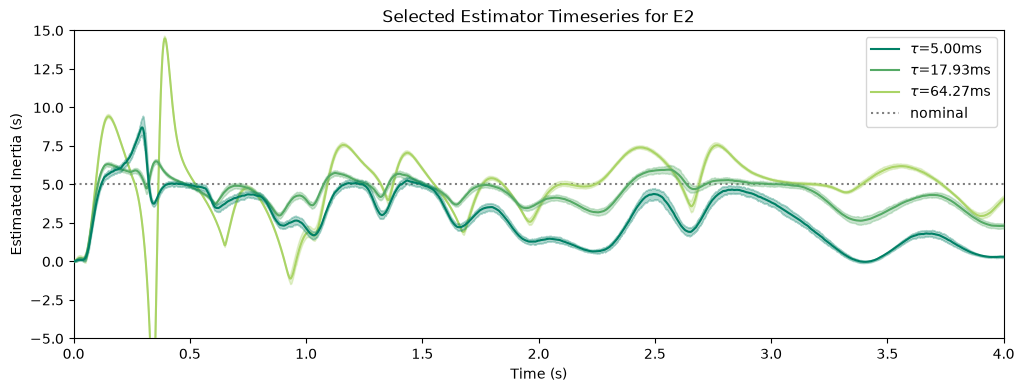

In [159]:
fig, ax = plt.subplots(figsize=(12, 4))
taus_to_plot = taus[::7]
color = colors[est]

print(taus_to_plot)

for i, tau in enumerate(taus_to_plot):
    ts = est_series[tau]
    ax.fill_between(ts.index, ts["q25"], ts["q75"], color=color[i], alpha=0.3, zorder = 10-i) # IQR slightly translucent band
    ax.plot(ts.index, ts["q50"], color=color[i], label=f"$\\tau$={float(tau):.2f}ms", zorder = 10 - i) # mean
    #print("hi")

ax.axline((0, 5), slope=0, color="gray", linestyle=":", label="nominal")
a = ax.legend(loc="upper right")
a.set_zorder(20)
ax.set_ylim(-5, 15)

ax.set_title(f"Selected Estimator Timeseries for {est}")
ax.set_xlabel("Time (s)")
ax.set_xlim(0, 4)
ax.set_ylabel("Estimated Inertia (s)")